# Validation Report: Unified Standalone Pipeline (`separation/*`)

Objective:
- Validate end-to-end parity of the three standalone modules against original Suite2p capture artifacts.
- Execute sequentially: `registration -> detection -> classification`.

Dual-path rule for classification:
- **Sequential path** (`det_out[1] -> classify`) is diagnostic and may differ from original capture.
- **Original-equivalent path** (`captured classification stat -> classify`) must match exactly.
- **Augmented-bridge path** (detection stat + injected `skew/std/snr`) should match exactly and demonstrates why dual-path is required.

Architecture / island constraints:
- Runtime imports from `suite2p` are blocked.
- Static scan enforces no `import suite2p` in standalone module files.


In [1]:
from __future__ import annotations

import builtins
import importlib
import importlib.util
import json
import pickle
import re
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

if any(name == "suite2p" or name.startswith("suite2p.") for name in sys.modules):
    raise RuntimeError(
        "Architecture rule violation: `suite2p` is already loaded in this kernel. "
        "Restart the kernel and run this notebook from the top."
    )


class BlockSuite2PImports:
    # Block suite2p imports to prevent namespace pollution.
    def __enter__(self):
        self._orig_import = builtins.__import__

        def guarded_import(name, globals=None, locals=None, fromlist=(), level=0):
            if name == "suite2p" or name.startswith("suite2p."):
                raise ImportError(f"Blocked import by architecture rule: {name}")
            return self._orig_import(name, globals, locals, fromlist, level)

        builtins.__import__ = guarded_import
        return self

    def __exit__(self, exc_type, exc_val, exc_tb):
        builtins.__import__ = self._orig_import


def find_repo_root(start: Path):
    current = start.resolve()
    for candidate in [current, *current.parents]:
        if (candidate / ".git").exists():
            return candidate
    return None


def load_module_from_file(module_name: str, file_path: Path):
    spec = importlib.util.spec_from_file_location(module_name, str(file_path))
    if spec is None or spec.loader is None:
        raise ImportError(f"Failed to create spec for {module_name} from {file_path}")
    module = importlib.util.module_from_spec(spec)
    sys.modules[module_name] = module
    spec.loader.exec_module(module)
    return module


def import_helper(module_path: str, attr: str, local_file: Path, local_module_name: str, repo_root: Path | None):
    try:
        mod = importlib.import_module(module_path)
        return getattr(mod, attr), "standard"
    except Exception:
        pass

    if repo_root is not None:
        repo_root_str = str(repo_root)
        if repo_root_str not in sys.path:
            sys.path.insert(0, repo_root_str)
        try:
            mod = importlib.import_module(module_path)
            return getattr(mod, attr), "repo_root_bootstrap"
        except Exception:
            pass

    if not local_file.exists():
        raise FileNotFoundError(f"Local helper source not found: {local_file}")
    mod = load_module_from_file(local_module_name, local_file)
    return getattr(mod, attr), "local_loader"


def import_standalone_package(module_path: str, package_dir: Path, local_name: str, repo_root: Path | None):
    try:
        mod = importlib.import_module(module_path)
        return mod, module_path, "standard"
    except Exception:
        pass

    if repo_root is not None:
        repo_root_str = str(repo_root)
        if repo_root_str not in sys.path:
            sys.path.insert(0, repo_root_str)
        try:
            mod = importlib.import_module(module_path)
            return mod, module_path, "repo_root_bootstrap"
        except Exception:
            pass

    init_file = package_dir / "__init__.py"
    if not init_file.exists():
        raise FileNotFoundError(f"Standalone package init not found: {init_file}")

    spec = importlib.util.spec_from_file_location(
        local_name,
        str(init_file),
        submodule_search_locations=[str(package_dir)],
    )
    if spec is None or spec.loader is None:
        raise ImportError(f"Failed to create package spec from {init_file}")

    mod = importlib.util.module_from_spec(spec)
    sys.modules[local_name] = mod
    spec.loader.exec_module(mod)
    return mod, local_name, "local_loader"


def assert_island_rule_static(package_dirs: dict[str, Path]):
    pattern = re.compile(r"^\s*(?:from|import)\s+suite2p\b")
    offenders = []
    for module_name, root in package_dirs.items():
        for py_path in root.rglob("*.py"):
            if "__pycache__" in py_path.parts:
                continue
            for lineno, line in enumerate(py_path.read_text().splitlines(), start=1):
                if pattern.search(line):
                    offenders.append(f"[{module_name}] {py_path}:{lineno}: {line.strip()}")
    if offenders:
        raise AssertionError("Island rule violation: found suite2p imports\n" + "\n".join(offenders))
    return True


def normalize_builtin_classfile(classfile, class_pkg_dir: Path):
    if classfile is None:
        return classfile
    if str(classfile).endswith("/suite2p/classifiers/classifier.npy"):
        return class_pkg_dir / "classifiers" / "classifier.npy"
    return classfile


notebook_dir = Path.cwd().resolve()
repo_root = find_repo_root(notebook_dir)
if repo_root is None:
    raise RuntimeError("Could not locate repo root (.git)")

sep_root = repo_root / "separation"
module_dirs = {
    "registration": sep_root / "registration",
    "detection": sep_root / "detection",
    "classification": sep_root / "classification",
}

reg_deserialize, reg_deser_import_strategy = import_helper(
    "separation.registration.serialization",
    "deserialize_object",
    module_dirs["registration"] / "serialization.py",
    "standalone_registration_serialization_local",
    repo_root,
)

det_deserialize, det_deser_import_strategy = import_helper(
    "separation.detection.serialization",
    "deserialize_object",
    module_dirs["detection"] / "serialization.py",
    "standalone_detection_serialization_local",
    repo_root,
)

cls_deserialize, cls_deser_import_strategy = import_helper(
    "separation.classification.serialization",
    "deserialize_object",
    module_dirs["classification"] / "serialization.py",
    "standalone_classification_serialization_local",
    repo_root,
)

BinaryFile, binary_import_strategy = import_helper(
    "separation.registration.binary",
    "BinaryFile",
    module_dirs["registration"] / "binary.py",
    "standalone_registration_binary_local",
    repo_root,
)

architecture_guard_initialized = True
print("Architecture guard initialized.")
print(f"Python={sys.version.split()[0]}")
print(f"repo_root={repo_root}")
print("import_strategies=")
print(
    json.dumps(
        {
            "registration_deserializer": reg_deser_import_strategy,
            "detection_deserializer": det_deser_import_strategy,
            "classification_deserializer": cls_deser_import_strategy,
            "binary_file": binary_import_strategy,
        },
        indent=2,
    )
)


Architecture guard initialized.
Python=3.9.25
repo_root=/home/yz/suite2p
import_strategies=
{
  "registration_deserializer": "repo_root_bootstrap",
  "detection_deserializer": "standard",
  "classification_deserializer": "standard",
  "binary_file": "standard"
}


In [2]:
artifact_dirs = {
    name: module_dirs[name]
    for name in ("registration", "detection", "classification")
}

required_names = ["test_input.pkl", "test_output.pkl", "capture_manifest.json"]
missing = []
for name, root in artifact_dirs.items():
    for req in required_names:
        path = root / req
        if not path.exists():
            missing.append(str(path))

if missing:
    raise FileNotFoundError("Missing required artifacts:\n" + "\n".join(missing))

manifests = {}
for name, root in artifact_dirs.items():
    manifests[name] = json.loads((root / "capture_manifest.json").read_text())

print("Artifact roots:")
for name, root in artifact_dirs.items():
    print(f"- {name:14s} {root}")

print("\nCapture summaries:")
for name in ("registration", "detection", "classification"):
    m = manifests[name]
    print(f"\n[{name}]")
    print("  captured_at_utc:", m.get("captured_at_utc"))
    print("  run_dir:", m.get("run_dir"))
    print("  file_name:", m.get("file_name"))
    print("  device:", m.get("device"))
    print("  settings_run:", m.get("settings_run"))


Artifact roots:
- registration   /home/yz/suite2p/separation/registration
- detection      /home/yz/suite2p/separation/detection
- classification /home/yz/suite2p/separation/classification

Capture summaries:

[registration]
  captured_at_utc: 2026-02-13T03:03:05.846243+00:00
  run_dir: /mnt/nas02/Dataset/suite2p/output/registration_capture/run_20260213T030243Z
  file_name: file_00002_00001.tif
  device: cpu
  settings_run: {'do_registration': 1, 'do_regmetrics': False, 'do_detection': False, 'do_deconvolution': False, 'multiplane_parallel': False}

[detection]
  captured_at_utc: 2026-02-28T02:56:44.771074+00:00
  run_dir: /mnt/nas02/Dataset/suite2p/output/detection_capture/run_20260228T025615Z
  file_name: file_00002_00001.tif
  device: cpu
  settings_run: {'do_registration': 1, 'do_regmetrics': False, 'do_detection': True, 'do_deconvolution': False, 'multiplane_parallel': False}

[classification]
  captured_at_utc: 2026-02-28T14:23:55.036823+00:00
  run_dir: /mnt/nas02/Dataset/suite2

In [3]:
serialized = {}
for name, root in artifact_dirs.items():
    with (root / "test_input.pkl").open("rb") as f:
        test_input = pickle.load(f)
    with (root / "test_output.pkl").open("rb") as f:
        test_output = pickle.load(f)
    serialized[name] = {"input": test_input, "output": test_output}

for name in ("registration", "detection", "classification"):
    s = serialized[name]
    print(f"[{name}] input_type={type(s['input']).__name__} output_type={type(s['output']).__name__}")
    if isinstance(s["input"], dict):
        print("  input keys:", sorted(s["input"].keys()))
    if isinstance(s["output"], dict) and "__type__" in s["output"]:
        print("  output serialized type:", s["output"]["__type__"])
    elif isinstance(s["output"], dict):
        print("  output keys:", sorted(s["output"].keys()))


[registration] input_type=dict output_type=dict
  input keys: ['align_by_chan2', 'aspect', 'badframes', 'device', 'f_raw', 'f_raw_chan2', 'f_reg', 'f_reg_chan2', 'refImg', 'save_path', 'settings']
  output keys: ['badframes', 'badframes0', 'bidiphase', 'corrXY', 'corrXY1', 'meanImg', 'meanImgE', 'refImg', 'rmax', 'rmin', 'xoff', 'xoff1', 'xrange', 'yoff', 'yoff1', 'yrange']
[detection] input_type=dict output_type=dict
  input keys: ['badframes', 'classifier_path', 'device', 'diameter', 'f_reg', 'fs', 'meanImg_chan2', 'mov', 'preclassify', 'settings', 'tau', 'xrange', 'yrange']
  output serialized type: tuple
[classification] input_type=dict output_type=dict
  input keys: ['classfile', 'keys', 'stat']
  output serialized type: ndarray


In [4]:
opened_binary_handles = []

def build_binary_file(desc):
    required = ("filename", "Ly", "Lx", "n_frames", "dtype", "write")
    miss = [k for k in required if k not in desc]
    if miss:
        raise ValueError(f"Binary descriptor missing keys {miss}: {desc}")

    filename = Path(desc["filename"])
    if not filename.exists():
        raise FileNotFoundError(f"Binary file not found: {filename}")

    bf = BinaryFile(
        Ly=int(desc["Ly"]),
        Lx=int(desc["Lx"]),
        filename=str(filename),
        n_frames=int(desc["n_frames"]),
        dtype=str(desc["dtype"]),
        write=bool(desc["write"]),
    )
    opened_binary_handles.append(bf)
    return bf

reg_kwargs = reg_deserialize(serialized["registration"]["input"], binary_file_factory=build_binary_file)
reg_expected = reg_deserialize(serialized["registration"]["output"])

det_kwargs_captured = det_deserialize(serialized["detection"]["input"], binary_file_factory=build_binary_file)
det_expected = det_deserialize(serialized["detection"]["output"])

cls_kwargs_captured = cls_deserialize(serialized["classification"]["input"])
cls_expected = cls_deserialize(serialized["classification"]["output"])

if not isinstance(cls_kwargs_captured, dict):
    raise TypeError(f"Expected classification kwargs as dict, got {type(cls_kwargs_captured).__name__}")

cls_kwargs_captured = dict(cls_kwargs_captured)
cls_kwargs_captured["classfile"] = normalize_builtin_classfile(
    cls_kwargs_captured.get("classfile"),
    module_dirs["classification"],
)

print("Deserialized summaries:")
print("- reg_kwargs keys:", sorted(reg_kwargs.keys()))
print("- det_kwargs_captured keys:", sorted(det_kwargs_captured.keys()))
print("- cls_kwargs_captured keys:", sorted(cls_kwargs_captured.keys()))
print("- len(cls_kwargs_captured['stat']):", len(cls_kwargs_captured.get("stat", [])))
print("- cls_expected shape:", getattr(cls_expected, "shape", None))


Deserialized summaries:
- reg_kwargs keys: ['align_by_chan2', 'aspect', 'badframes', 'device', 'f_raw', 'f_raw_chan2', 'f_reg', 'f_reg_chan2', 'refImg', 'save_path', 'settings']
- det_kwargs_captured keys: ['badframes', 'classifier_path', 'device', 'diameter', 'f_reg', 'fs', 'meanImg_chan2', 'mov', 'preclassify', 'settings', 'tau', 'xrange', 'yrange']
- cls_kwargs_captured keys: ['classfile', 'keys', 'stat']
- len(cls_kwargs_captured['stat']): 77
- cls_expected shape: (77, 2)


In [5]:
island_rule_static_ok = assert_island_rule_static(module_dirs)
print("Island-rule static scan passed:", island_rule_static_ok)


Island-rule static scan passed: True


In [6]:
architecture_guard_status = False
execution_import_strategies = {}

reg_out = None
det_out = None
cls_seq_out = None
cls_seq_out_repeat = None
cls_parity_out = None
cls_aug_out = None

reg_module_name = None
det_module_name = None
cls_module_name = None

try:
    with BlockSuite2PImports():
        reg_module, reg_module_name, reg_imp = import_standalone_package(
            "separation.registration",
            module_dirs["registration"],
            "standalone_registration_local",
            repo_root,
        )
        det_module, det_module_name, det_imp = import_standalone_package(
            "separation.detection",
            module_dirs["detection"],
            "standalone_detection_local",
            repo_root,
        )
        cls_module, cls_module_name, cls_imp = import_standalone_package(
            "separation.classification",
            module_dirs["classification"],
            "standalone_classification_local",
            repo_root,
        )
        architecture_guard_status = True

        execution_import_strategies = {
            "registration": reg_imp,
            "detection": det_imp,
            "classification": cls_imp,
        }

        # 1) Registration
        reg_out = reg_module.registration_wrapper(**reg_kwargs)

        # 2) Detection chained from registration output
        det_kwargs_chain = dict(det_kwargs_captured)
        det_kwargs_chain["f_reg"] = reg_kwargs["f_reg"]
        det_kwargs_chain["yrange"] = reg_out["yrange"]
        det_kwargs_chain["xrange"] = reg_out["xrange"]
        det_kwargs_chain["badframes"] = np.logical_or(
            reg_out["badframes"], np.array(reg_kwargs["badframes"], dtype=bool)
        )
        det_kwargs_chain["meanImg_chan2"] = reg_out.get("meanImg_chan2", None)
        det_out = det_module.detection_wrapper(**det_kwargs_chain)

        # 3) Classification sequential path (diagnostic)
        cls_seq_kwargs = dict(cls_kwargs_captured)
        cls_seq_kwargs["stat"] = det_out[1]
        cls_seq_out = cls_module.classify(**cls_seq_kwargs)
        cls_seq_out_repeat = cls_module.classify(**cls_seq_kwargs)

        # 4) Classification parity path (must match captured output)
        cls_parity_out = cls_module.classify(**cls_kwargs_captured)

        # 5) Classification augmented-bridge path (must match captured output)
        stat_det = det_out[1]
        stat_cap = cls_kwargs_captured["stat"]
        if len(stat_det) != len(stat_cap):
            raise ValueError(
                f"ROI count mismatch for augmented bridge: len(stat_det)={len(stat_det)} != len(stat_cap)={len(stat_cap)}"
            )

        stat_augmented = np.array([dict(s) for s in stat_det], dtype=object)
        for i in range(len(stat_augmented)):
            for key in ("skew", "std", "snr"):
                if key in stat_cap[i]:
                    stat_augmented[i][key] = stat_cap[i][key]

        cls_aug_kwargs = dict(cls_kwargs_captured)
        cls_aug_kwargs["stat"] = stat_augmented
        cls_aug_out = cls_module.classify(**cls_aug_kwargs)

finally:
    for bf in opened_binary_handles:
        try:
            bf.close()
        except Exception as exc:
            print(
                "Warning: failed to close binary handle",
                getattr(bf, "filename", "<unknown>"),
                exc,
            )

print("Execution complete.")
print("architecture_guard_status:", architecture_guard_status)
print("module_names:", reg_module_name, det_module_name, cls_module_name)
print("execution_import_strategies:", execution_import_strategies)
print("detected_rois:", len(det_out[1]) if det_out is not None else None)
print("classification_shapes:")
print("  seq:", getattr(cls_seq_out, "shape", None))
print("  parity:", getattr(cls_parity_out, "shape", None))
print("  augmented:", getattr(cls_aug_out, "shape", None))


/home/yz/suite2p/separation/registration/register.py:571: UserWarning: The given NumPy array is not writable, and PyTorch does not support non-writable tensors. This means writing to this tensor will result in undefined behavior. You may want to copy the array to protect its data or make it writable before converting it to a tensor. This type of warning will be suppressed for the rest of this program. (Triggered internally at /pytorch/torch/csrc/utils/tensor_numpy.cpp:203.)
  fr_torch = torch.from_numpy(frames).to(device)


Execution complete.
architecture_guard_status: True
module_names: separation.registration separation.detection separation.classification
execution_import_strategies: {'registration': 'standard', 'detection': 'standard', 'classification': 'standard'}
detected_rois: 77
classification_shapes:
  seq: (77, 2)
  parity: (77, 2)
  augmented: (77, 2)


In [7]:
comparison_rows = []


def add_row(path, kind, expected, actual, passed, detail, max_abs_error=None):
    shape_expected = tuple(expected.shape) if isinstance(expected, np.ndarray) else None
    shape_actual = tuple(actual.shape) if isinstance(actual, np.ndarray) else None
    comparison_rows.append(
        {
            "path": path,
            "kind": kind,
            "shape_expected": shape_expected,
            "shape_actual": shape_actual,
            "pass": bool(passed),
            "max_abs_error": max_abs_error,
            "detail": detail,
        }
    )


def compare_objects(expected, actual, path="root"):
    if isinstance(expected, dict):
        if not isinstance(actual, dict):
            add_row(path, "dict", expected, actual, False, f"type mismatch: expected dict, got {type(actual).__name__}")
            return

        expected_keys = set(expected.keys())
        actual_keys = set(actual.keys())
        if expected_keys != actual_keys:
            missing = sorted(expected_keys - actual_keys)
            extra = sorted(actual_keys - expected_keys)
            add_row(path, "dict_keys", expected, actual, False, f"key mismatch; missing={missing}, extra={extra}")

        for key in sorted(expected_keys & actual_keys):
            compare_objects(expected[key], actual[key], path=f"{path}.{key}")
        return

    if isinstance(expected, tuple):
        if not isinstance(actual, tuple):
            add_row(path, "tuple", expected, actual, False, f"type mismatch: expected tuple, got {type(actual).__name__}")
            return
        if len(expected) != len(actual):
            add_row(path, "tuple_len", expected, actual, False, f"length mismatch: {len(expected)} != {len(actual)}")
        for idx, (exp_item, act_item) in enumerate(zip(expected, actual)):
            compare_objects(exp_item, act_item, path=f"{path}[{idx}]")
        return

    if isinstance(expected, list):
        if not isinstance(actual, list):
            add_row(path, "list", expected, actual, False, f"type mismatch: expected list, got {type(actual).__name__}")
            return
        if len(expected) != len(actual):
            add_row(path, "list_len", expected, actual, False, f"length mismatch: {len(expected)} != {len(actual)}")
        for idx, (exp_item, act_item) in enumerate(zip(expected, actual)):
            compare_objects(exp_item, act_item, path=f"{path}[{idx}]")
        return

    if isinstance(expected, np.ndarray):
        if not isinstance(actual, np.ndarray):
            add_row(path, "ndarray", expected, actual, False, f"type mismatch: expected ndarray, got {type(actual).__name__}")
            return

        if expected.dtype != actual.dtype:
            add_row(path, "ndarray_dtype", expected, actual, False, f"dtype mismatch: {expected.dtype} != {actual.dtype}")
            return

        if expected.shape != actual.shape:
            add_row(path, "ndarray_shape", expected, actual, False, f"shape mismatch: {expected.shape} != {actual.shape}")
            return

        if expected.dtype == object:
            for idx in np.ndindex(expected.shape):
                compare_objects(expected[idx], actual[idx], path=f"{path}[{idx}]")
            return

        if np.issubdtype(expected.dtype, np.floating):
            diff = np.abs(expected.astype(np.float64) - actual.astype(np.float64))
            max_abs_error = float(np.nanmax(diff)) if diff.size else 0.0
            try:
                np.testing.assert_allclose(expected, actual, rtol=0.0, atol=0.0, equal_nan=True)
                add_row(path, "ndarray_float", expected, actual, True, "exact float match", max_abs_error=max_abs_error)
            except AssertionError as exc:
                add_row(path, "ndarray_float", expected, actual, False, str(exc).splitlines()[0], max_abs_error=max_abs_error)
        else:
            passed = bool(np.array_equal(expected, actual))
            add_row(path, "ndarray_exact", expected, actual, passed, "exact array match" if passed else "array values differ")
        return

    if type(expected) is not type(actual):
        add_row(path, "scalar_type", expected, actual, False, f"type mismatch: {type(expected).__name__} != {type(actual).__name__}")
        return

    passed = expected == actual
    add_row(path, "scalar", expected, actual, passed, "exact scalar match" if passed else f"value mismatch: {expected!r} != {actual!r}")


compare_objects(reg_expected, reg_out, path="registration")
compare_objects(det_expected, det_out, path="detection")
compare_objects(cls_expected, cls_seq_out, path="classification_seq")
compare_objects(cls_expected, cls_parity_out, path="classification_parity")
compare_objects(cls_expected, cls_aug_out, path="classification_aug")
compare_objects(cls_seq_out, cls_seq_out_repeat, path="classification_repeat")


def stage_result(prefix: str):
    rows = [r for r in comparison_rows if r["path"] == prefix or r["path"].startswith(prefix + ".") or r["path"].startswith(prefix + "[")]
    passed = bool(rows) and all(r["pass"] for r in rows)
    float_errors = [r["max_abs_error"] for r in rows if r["max_abs_error"] is not None]
    max_abs_error = max(float_errors) if float_errors else None
    return {
        "pass": passed,
        "n_checks": len(rows),
        "max_abs_error": max_abs_error,
        "failed_rows": [r for r in rows if not r["pass"]],
    }

registration_stage = stage_result("registration")
detection_stage = stage_result("detection")
classification_seq_stage = stage_result("classification_seq")
classification_parity_stage = stage_result("classification_parity")
classification_aug_stage = stage_result("classification_aug")
classification_repeat_stage = stage_result("classification_repeat")

registration_exact_pass = registration_stage["pass"]
detection_exact_pass = detection_stage["pass"]
classification_seq_exact_pass = classification_seq_stage["pass"]
classification_parity_exact_pass = classification_parity_stage["pass"]
classification_aug_exact_pass = classification_aug_stage["pass"]
classification_seq_repeat_pass = classification_repeat_stage["pass"]

print("Stage verdicts:")
for name, info in [
    ("registration", registration_stage),
    ("detection", detection_stage),
    ("classification_seq", classification_seq_stage),
    ("classification_parity", classification_parity_stage),
    ("classification_aug", classification_aug_stage),
    ("classification_repeat", classification_repeat_stage),
]:
    print(f"- {name:22s} PASS={info['pass']} checks={info['n_checks']} max_abs_error={info['max_abs_error']}")

all_failed = [r for r in comparison_rows if not r["pass"]]
print(f"\nTotal checks={len(comparison_rows)} failed={len(all_failed)}")
if all_failed:
    print("First failed rows:")
    for r in all_failed[:20]:
        print(f"  - {r['path']} | {r['kind']} | {r['detail']} | max_abs_error={r['max_abs_error']}")


Stage verdicts:
- registration           PASS=True checks=18 max_abs_error=0.0
- detection              PASS=True checks=1323 max_abs_error=0.0
- classification_seq     PASS=False checks=1 max_abs_error=1.0
- classification_parity  PASS=True checks=1 max_abs_error=0.0
- classification_aug     PASS=True checks=1 max_abs_error=0.0
- classification_repeat  PASS=True checks=1 max_abs_error=0.0

Total checks=1345 failed=1
First failed rows:
  - classification_seq | ndarray_float |  | max_abs_error=1.0


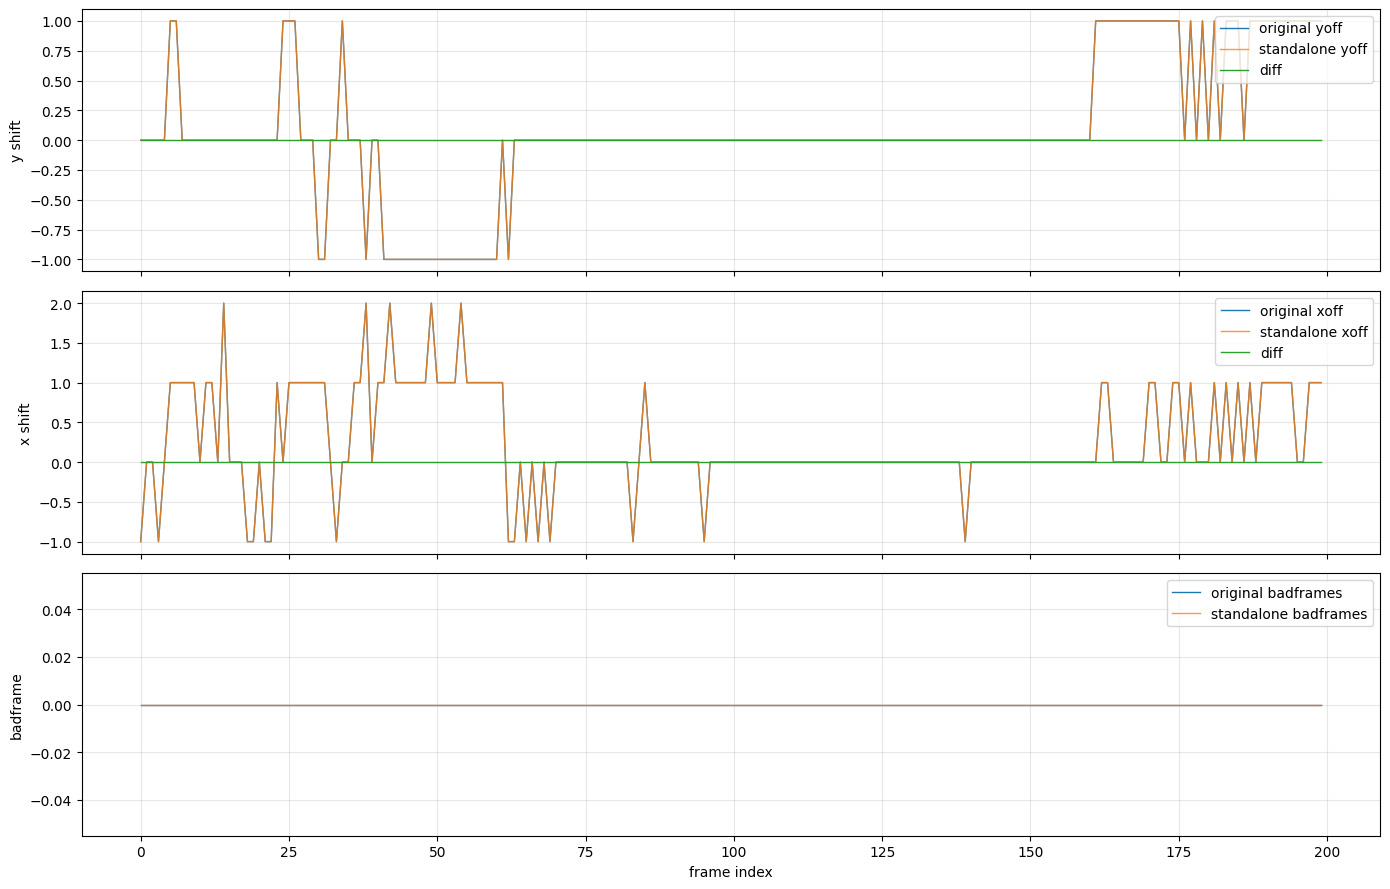

Registration max abs errors:
- yoff: 0.0
- xoff: 0.0
- badframe mismatches: 0


In [8]:
# Registration visualization: offsets and badframes

exp_yoff = np.asarray(reg_expected["yoff"]).astype(np.float64)
new_yoff = np.asarray(reg_out["yoff"]).astype(np.float64)
exp_xoff = np.asarray(reg_expected["xoff"]).astype(np.float64)
new_xoff = np.asarray(reg_out["xoff"]).astype(np.float64)

yoff_diff = exp_yoff - new_yoff
xoff_diff = exp_xoff - new_xoff
bad_expected = np.asarray(reg_expected["badframes"]).astype(bool)
bad_new = np.asarray(reg_out["badframes"]).astype(bool)

fig, axes = plt.subplots(3, 1, figsize=(14, 9), sharex=True)

axes[0].plot(exp_yoff, label="original yoff", linewidth=1)
axes[0].plot(new_yoff, label="standalone yoff", linewidth=1, alpha=0.8)
axes[0].plot(yoff_diff, label="diff", linewidth=1)
axes[0].set_ylabel("y shift")
axes[0].legend(loc="upper right")
axes[0].grid(alpha=0.3)

axes[1].plot(exp_xoff, label="original xoff", linewidth=1)
axes[1].plot(new_xoff, label="standalone xoff", linewidth=1, alpha=0.8)
axes[1].plot(xoff_diff, label="diff", linewidth=1)
axes[1].set_ylabel("x shift")
axes[1].legend(loc="upper right")
axes[1].grid(alpha=0.3)

axes[2].plot(bad_expected.astype(int), label="original badframes", linewidth=1)
axes[2].plot(bad_new.astype(int), label="standalone badframes", linewidth=1, alpha=0.8)
axes[2].set_ylabel("badframe")
axes[2].set_xlabel("frame index")
axes[2].legend(loc="upper right")
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.show()

print("Registration max abs errors:")
print("- yoff:", float(np.max(np.abs(yoff_diff))) if yoff_diff.size else 0.0)
print("- xoff:", float(np.max(np.abs(xoff_diff))) if xoff_diff.size else 0.0)
print("- badframe mismatches:", int(np.sum(bad_expected != bad_new)))


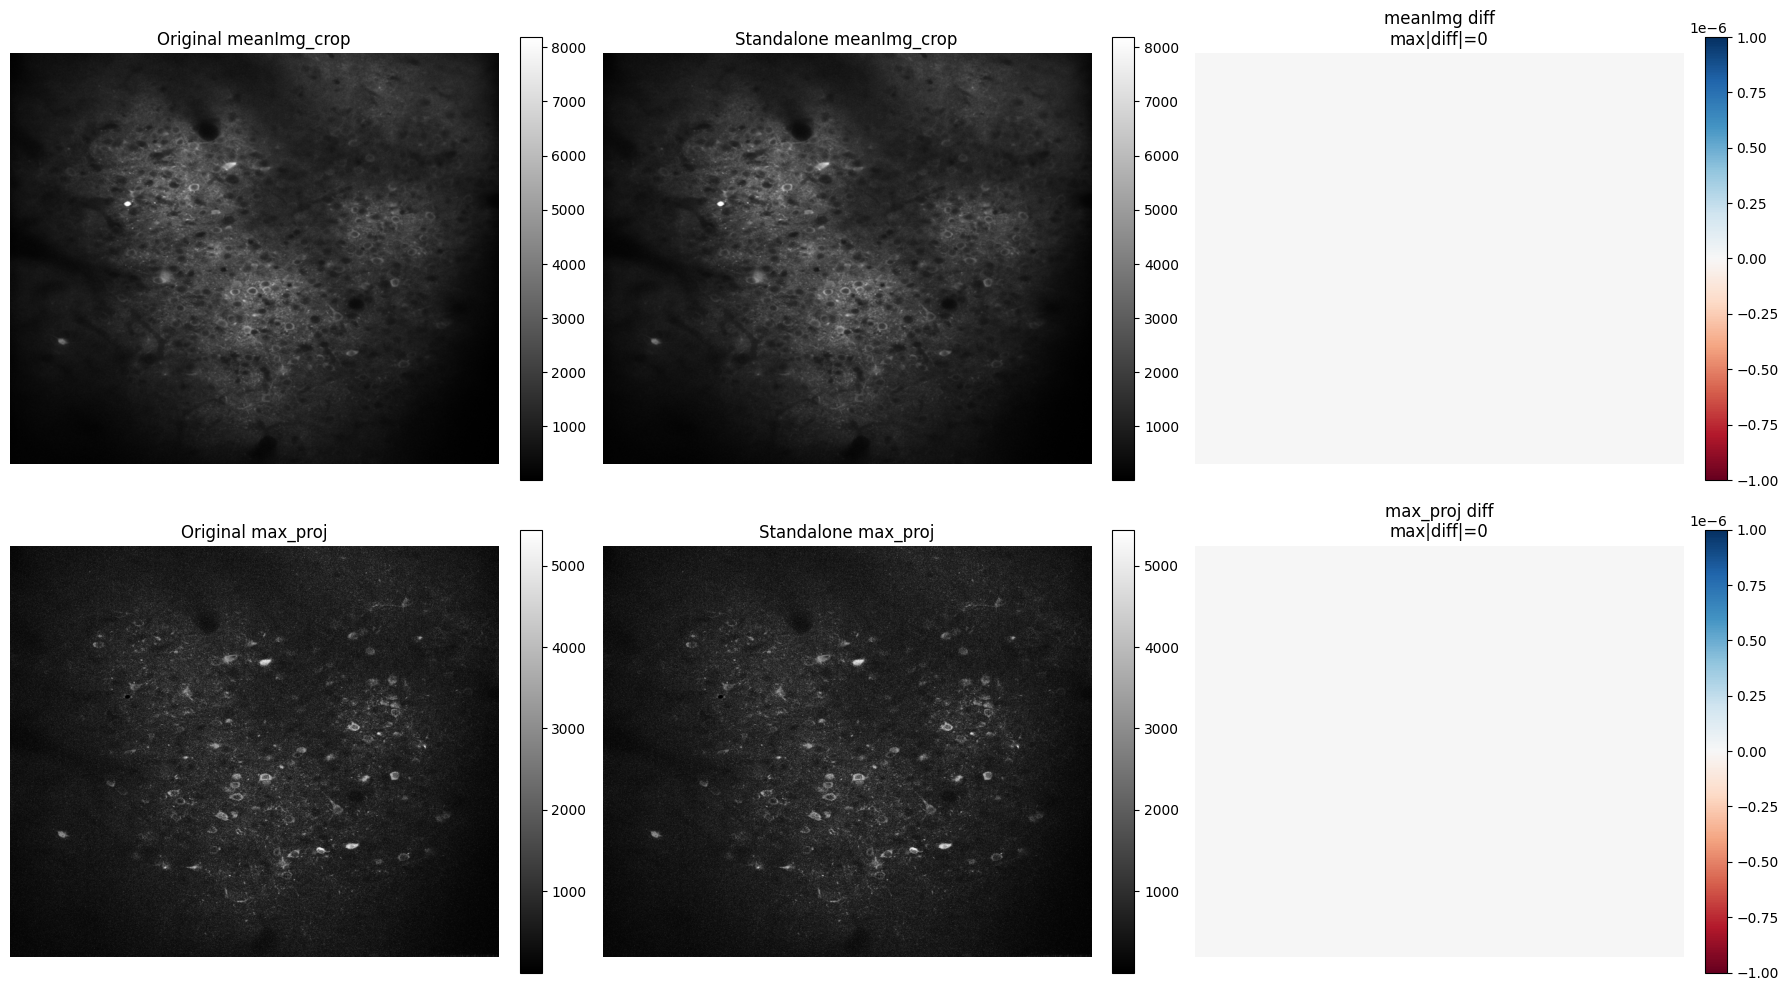

Detection image max abs errors:
- meanImg_crop: 0.0
- max_proj: 0.0


In [9]:
# Detection visualization: meanImg_crop and max_proj

exp_new_settings, exp_stat, exp_redcell = det_expected
new_new_settings, new_stat, new_redcell = det_out

exp_mean = exp_new_settings["meanImg_crop"].astype(np.float32)
new_mean = new_new_settings["meanImg_crop"].astype(np.float32)
mean_diff = exp_mean - new_mean
mean_diff_max = float(np.max(np.abs(mean_diff))) if mean_diff.size else 0.0
mean_vlim = mean_diff_max if mean_diff_max > 0 else 1e-6

exp_max = exp_new_settings["max_proj"].astype(np.float32)
new_max = new_new_settings["max_proj"].astype(np.float32)
max_diff = exp_max - new_max
max_diff_max = float(np.max(np.abs(max_diff))) if max_diff.size else 0.0
max_vlim = max_diff_max if max_diff_max > 0 else 1e-6

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

im = axes[0, 0].imshow(exp_mean, cmap="gray")
axes[0, 0].set_title("Original meanImg_crop")
axes[0, 0].axis("off")
plt.colorbar(im, ax=axes[0, 0], fraction=0.046, pad=0.04)

im = axes[0, 1].imshow(new_mean, cmap="gray")
axes[0, 1].set_title("Standalone meanImg_crop")
axes[0, 1].axis("off")
plt.colorbar(im, ax=axes[0, 1], fraction=0.046, pad=0.04)

im = axes[0, 2].imshow(mean_diff, cmap="RdBu", vmin=-mean_vlim, vmax=mean_vlim)
axes[0, 2].set_title(f"meanImg diff\nmax|diff|={mean_diff_max:.6g}")
axes[0, 2].axis("off")
plt.colorbar(im, ax=axes[0, 2], fraction=0.046, pad=0.04)

im = axes[1, 0].imshow(exp_max, cmap="gray")
axes[1, 0].set_title("Original max_proj")
axes[1, 0].axis("off")
plt.colorbar(im, ax=axes[1, 0], fraction=0.046, pad=0.04)

im = axes[1, 1].imshow(new_max, cmap="gray")
axes[1, 1].set_title("Standalone max_proj")
axes[1, 1].axis("off")
plt.colorbar(im, ax=axes[1, 1], fraction=0.046, pad=0.04)

im = axes[1, 2].imshow(max_diff, cmap="RdBu", vmin=-max_vlim, vmax=max_vlim)
axes[1, 2].set_title(f"max_proj diff\nmax|diff|={max_diff_max:.6g}")
axes[1, 2].axis("off")
plt.colorbar(im, ax=axes[1, 2], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()

print("Detection image max abs errors:")
print("- meanImg_crop:", mean_diff_max)
print("- max_proj:", max_diff_max)


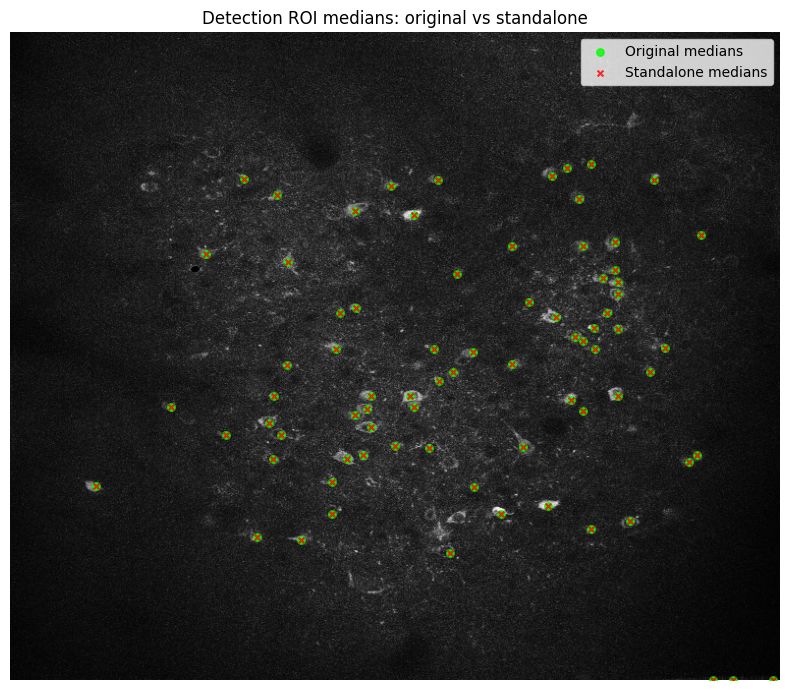

ROI counts:
- expected: 77
- standalone: 77
- diff: 0


In [10]:
# Detection visualization: ROI medians overlay

canvas = exp_new_settings["max_proj"].astype(np.float32)
exp_med = np.array([s["med"] for s in exp_stat], dtype=np.float32)
new_med = np.array([s["med"] for s in new_stat], dtype=np.float32)

roi_count_expected = len(exp_stat)
roi_count_new = len(new_stat)
roi_count_diff = roi_count_expected - roi_count_new

fig, ax = plt.subplots(figsize=(8, 8))
ax.imshow(canvas, cmap="gray")
if exp_med.size:
    ax.scatter(exp_med[:, 1], exp_med[:, 0], s=28, c="lime", alpha=0.8, label="Original medians")
if new_med.size:
    ax.scatter(new_med[:, 1], new_med[:, 0], s=18, c="red", marker="x", alpha=0.8, label="Standalone medians")
ax.set_title("Detection ROI medians: original vs standalone")
ax.axis("off")
ax.legend(loc="upper right")
plt.tight_layout()
plt.show()

print("ROI counts:")
print("- expected:", roi_count_expected)
print("- standalone:", roi_count_new)
print("- diff:", roi_count_diff)


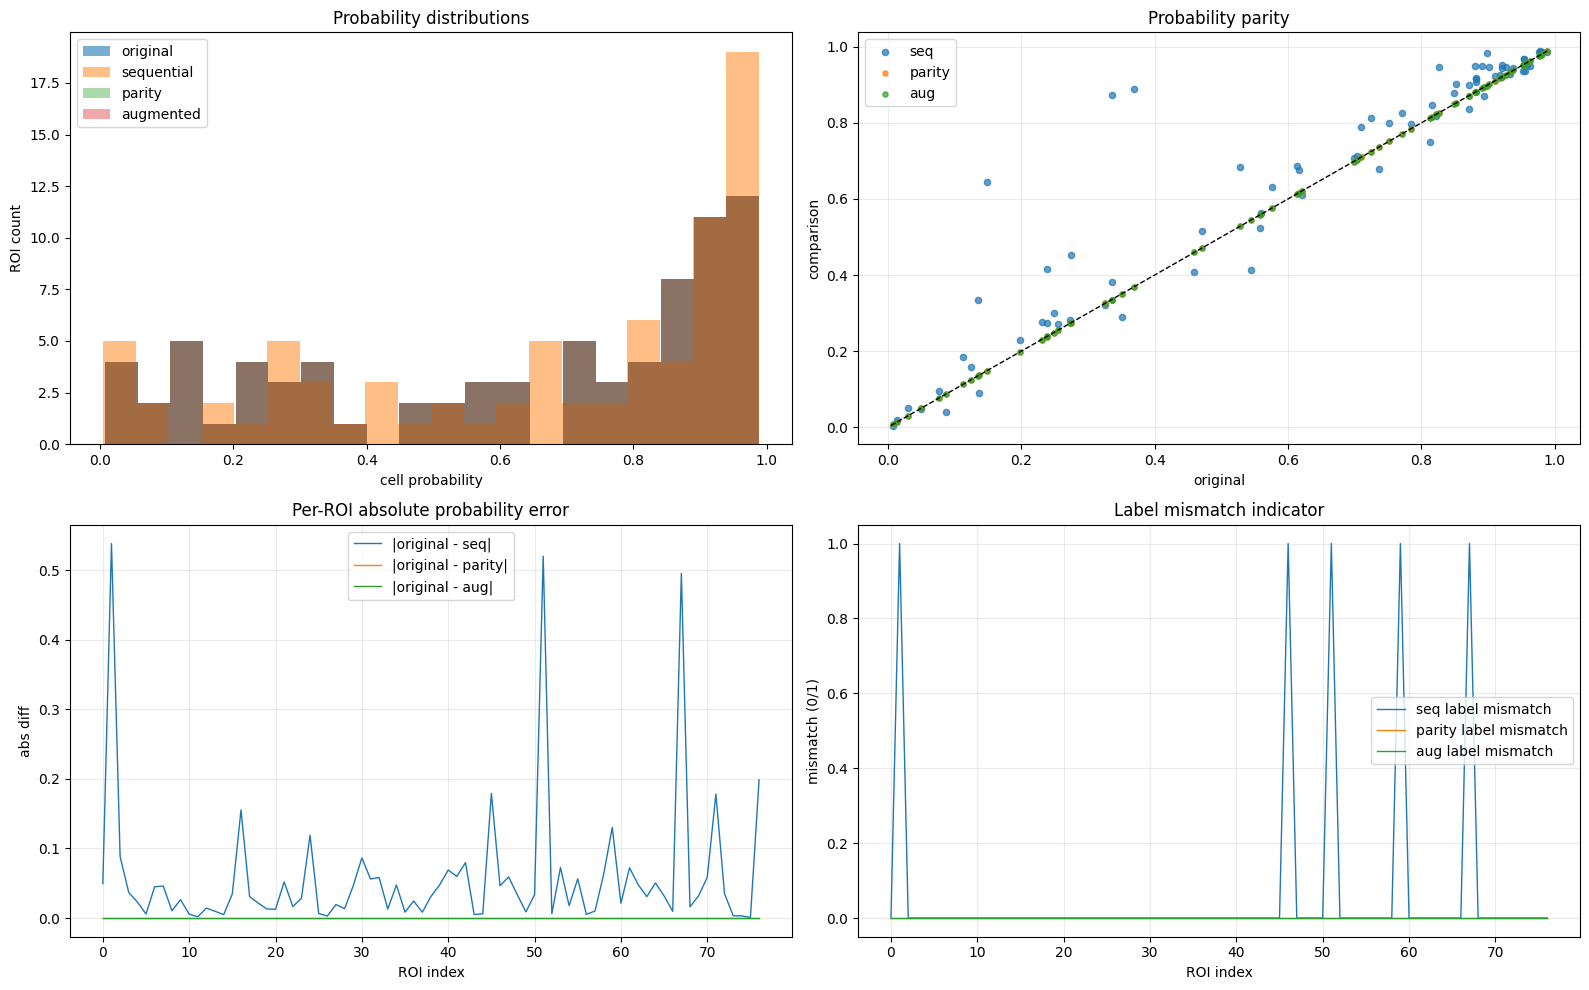

Classification mismatch counts:
- sequential: 5
- parity: 0
- augmented: 0


In [11]:
# Classification parity + filtering diagnostics

exp_prob = cls_expected[:, 1].astype(np.float64)
seq_prob = cls_seq_out[:, 1].astype(np.float64)
par_prob = cls_parity_out[:, 1].astype(np.float64)
aug_prob = cls_aug_out[:, 1].astype(np.float64)

exp_lbl = cls_expected[:, 0].astype(np.int64)
seq_lbl = cls_seq_out[:, 0].astype(np.int64)
par_lbl = cls_parity_out[:, 0].astype(np.int64)
aug_lbl = cls_aug_out[:, 0].astype(np.int64)

seq_label_mismatch = np.flatnonzero(exp_lbl != seq_lbl)
par_label_mismatch = np.flatnonzero(exp_lbl != par_lbl)
aug_label_mismatch = np.flatnonzero(exp_lbl != aug_lbl)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))

axes[0, 0].hist(exp_prob, bins=20, alpha=0.6, label="original", color="tab:blue")
axes[0, 0].hist(seq_prob, bins=20, alpha=0.5, label="sequential", color="tab:orange")
axes[0, 0].hist(par_prob, bins=20, alpha=0.4, label="parity", color="tab:green")
axes[0, 0].hist(aug_prob, bins=20, alpha=0.4, label="augmented", color="tab:red")
axes[0, 0].set_title("Probability distributions")
axes[0, 0].set_xlabel("cell probability")
axes[0, 0].set_ylabel("ROI count")
axes[0, 0].legend()

mn = float(min(exp_prob.min(), seq_prob.min(), par_prob.min(), aug_prob.min())) if exp_prob.size else 0.0
mx = float(max(exp_prob.max(), seq_prob.max(), par_prob.max(), aug_prob.max())) if exp_prob.size else 1.0

axes[0, 1].scatter(exp_prob, seq_prob, s=20, alpha=0.7, label="seq")
axes[0, 1].scatter(exp_prob, par_prob, s=14, alpha=0.7, label="parity")
axes[0, 1].scatter(exp_prob, aug_prob, s=14, alpha=0.7, label="aug")
axes[0, 1].plot([mn, mx], [mn, mx], "k--", linewidth=1)
axes[0, 1].set_title("Probability parity")
axes[0, 1].set_xlabel("original")
axes[0, 1].set_ylabel("comparison")
axes[0, 1].legend()
axes[0, 1].grid(alpha=0.25)

axes[1, 0].plot(np.abs(exp_prob - seq_prob), label="|original - seq|", linewidth=1)
axes[1, 0].plot(np.abs(exp_prob - par_prob), label="|original - parity|", linewidth=1)
axes[1, 0].plot(np.abs(exp_prob - aug_prob), label="|original - aug|", linewidth=1)
axes[1, 0].set_title("Per-ROI absolute probability error")
axes[1, 0].set_xlabel("ROI index")
axes[1, 0].set_ylabel("abs diff")
axes[1, 0].legend()
axes[1, 0].grid(alpha=0.25)

axes[1, 1].plot((exp_lbl != seq_lbl).astype(int), label="seq label mismatch", linewidth=1)
axes[1, 1].plot((exp_lbl != par_lbl).astype(int), label="parity label mismatch", linewidth=1)
axes[1, 1].plot((exp_lbl != aug_lbl).astype(int), label="aug label mismatch", linewidth=1)
axes[1, 1].set_title("Label mismatch indicator")
axes[1, 1].set_xlabel("ROI index")
axes[1, 1].set_ylabel("mismatch (0/1)")
axes[1, 1].legend()
axes[1, 1].grid(alpha=0.25)

plt.tight_layout()
plt.show()

print("Classification mismatch counts:")
print("- sequential:", len(seq_label_mismatch))
print("- parity:", len(par_label_mismatch))
print("- augmented:", len(aug_label_mismatch))


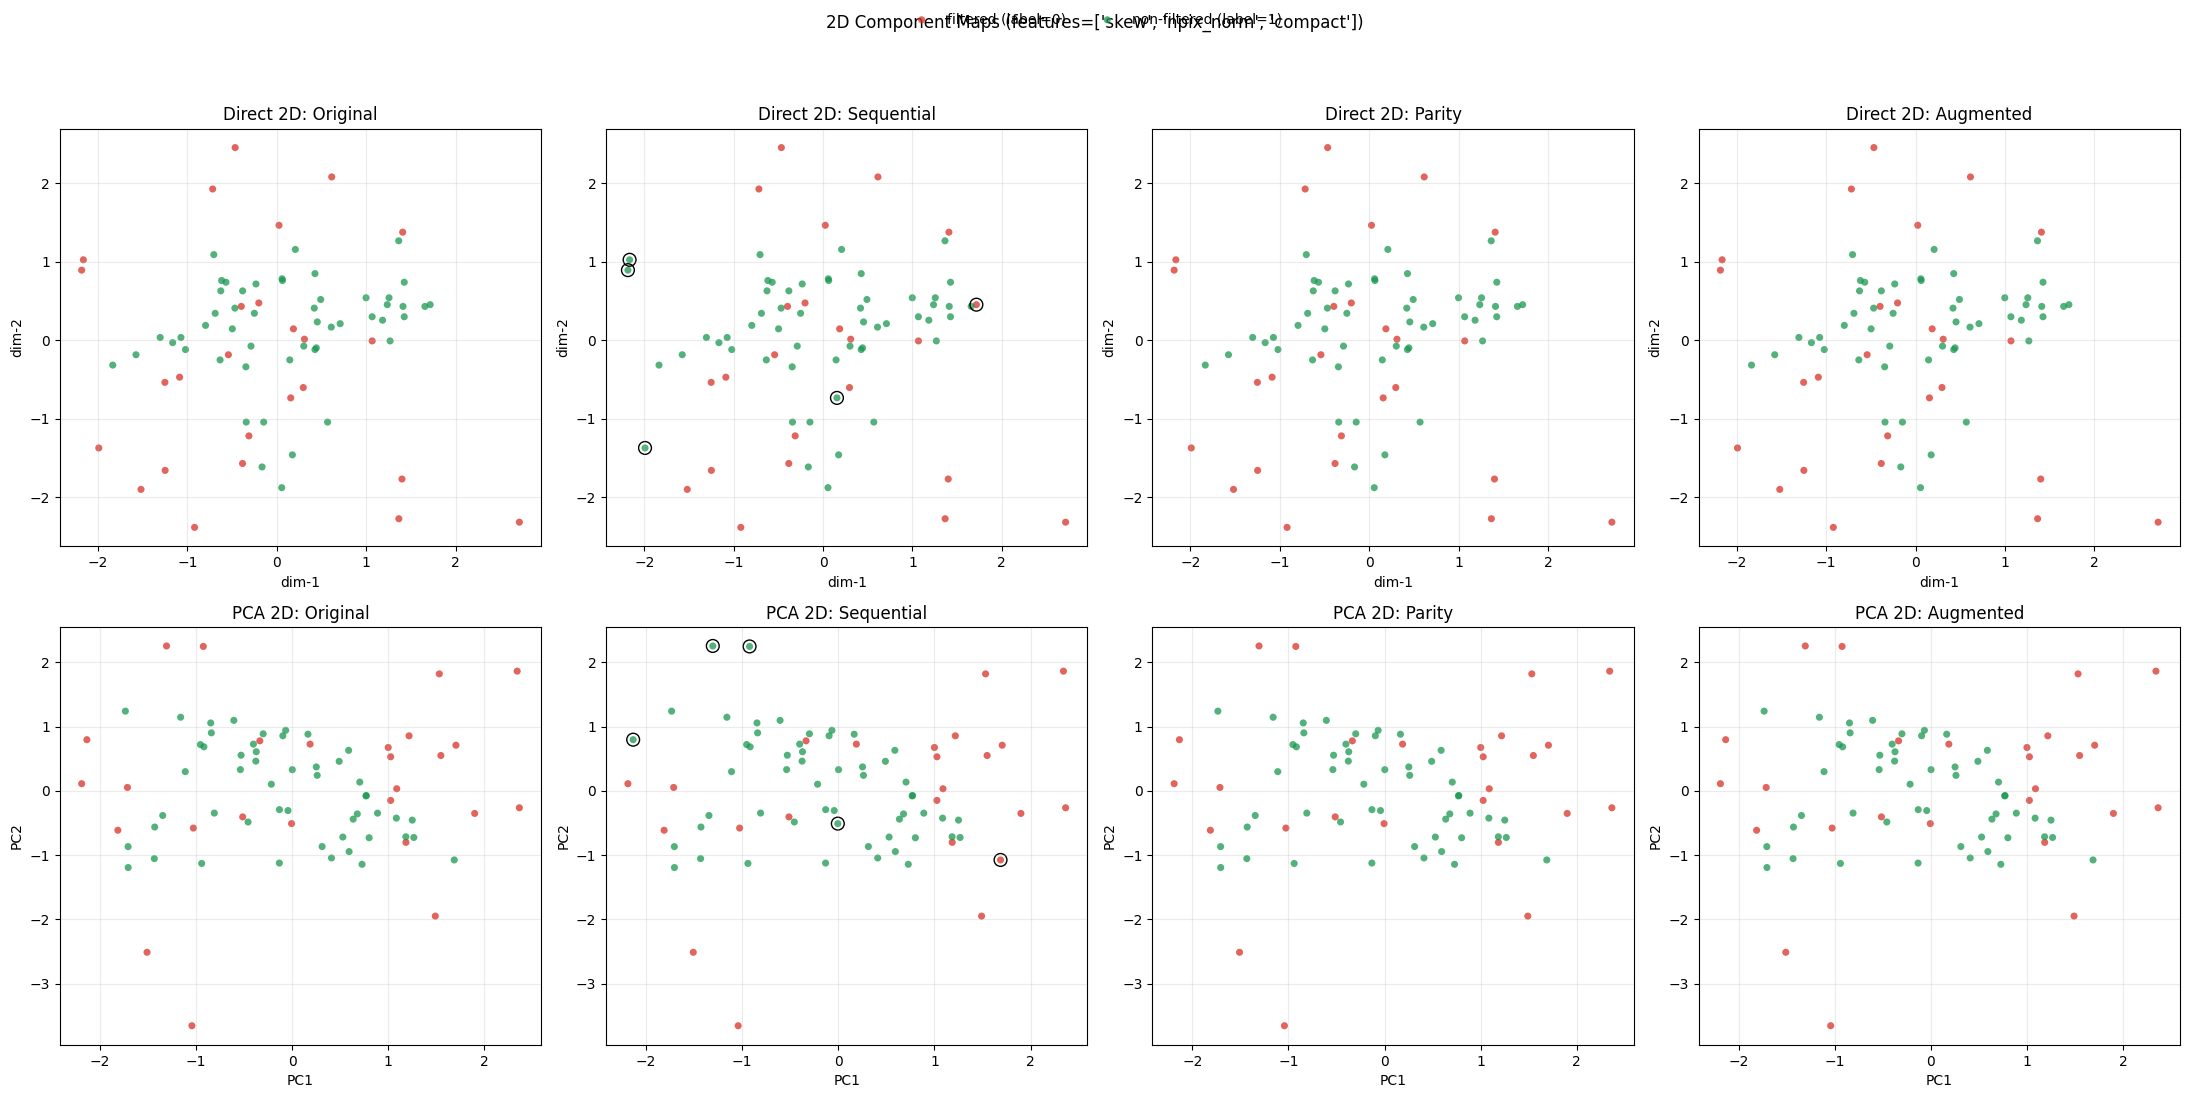

2D map diagnostics:
- feature_keys: ['skew', 'npix_norm', 'compact']
- n_components: 77
- mismatch seq/parity/aug: 5 0 0


In [12]:
# 2D filtered/non-filtered component maps

stat_for_embedding = cls_kwargs_captured["stat"]
feature_keys = list(cls_kwargs_captured.get("keys") or [])
feature_keys = [k for k in feature_keys if k in stat_for_embedding[0]]

if not feature_keys:
    numeric_keys = []
    for key, value in stat_for_embedding[0].items():
        if np.isscalar(value) and isinstance(value, (int, float, np.number)) and not isinstance(value, bool):
            numeric_keys.append(key)
    feature_keys = numeric_keys[:3]

if not feature_keys:
    raise RuntimeError("Could not determine numeric feature keys for 2D embedding")

X_raw = np.array(
    [[float(roi[k]) for k in feature_keys] for roi in stat_for_embedding],
    dtype=np.float64,
)
if X_raw.ndim == 1:
    X_raw = X_raw[:, np.newaxis]

mu = np.nanmean(X_raw, axis=0, keepdims=True)
sigma = np.nanstd(X_raw, axis=0, keepdims=True)
sigma[sigma == 0] = 1.0
X = np.nan_to_num((X_raw - mu) / sigma, nan=0.0, posinf=0.0, neginf=0.0)

if X.shape[1] >= 2:
    emb_direct = X[:, :2]
else:
    emb_direct = np.column_stack([X[:, 0], np.zeros(X.shape[0], dtype=np.float64)])

if X.shape[1] >= 2:
    _, _, vh = np.linalg.svd(X, full_matrices=False)
    emb_pca = X @ vh[:2].T
else:
    emb_pca = emb_direct.copy()

lbl_original = cls_expected[:, 0].astype(bool)
lbl_seq = cls_seq_out[:, 0].astype(bool)
lbl_par = cls_parity_out[:, 0].astype(bool)
lbl_aug = cls_aug_out[:, 0].astype(bool)


def draw_component_map(ax, points, labels, ref_labels, title):
    filtered = ~labels
    nonfiltered = labels
    mismatch = labels != ref_labels

    if filtered.any():
        ax.scatter(points[filtered, 0], points[filtered, 1], s=26, c="#D73027", alpha=0.75, label="filtered (label=0)", edgecolors="none")
    if nonfiltered.any():
        ax.scatter(points[nonfiltered, 0], points[nonfiltered, 1], s=26, c="#1A9850", alpha=0.75, label="non-filtered (label=1)", edgecolors="none")
    if mismatch.any():
        ax.scatter(points[mismatch, 0], points[mismatch, 1], s=85, facecolors="none", edgecolors="black", linewidths=1.0, label="mismatch vs original")

    ax.set_title(title)
    ax.grid(alpha=0.25)


fig, axes = plt.subplots(2, 4, figsize=(22, 11))

draw_component_map(axes[0, 0], emb_direct, lbl_original, lbl_original, "Direct 2D: Original")
draw_component_map(axes[0, 1], emb_direct, lbl_seq, lbl_original, "Direct 2D: Sequential")
draw_component_map(axes[0, 2], emb_direct, lbl_par, lbl_original, "Direct 2D: Parity")
draw_component_map(axes[0, 3], emb_direct, lbl_aug, lbl_original, "Direct 2D: Augmented")

for j in range(4):
    axes[0, j].set_xlabel("dim-1")
    axes[0, j].set_ylabel("dim-2")

draw_component_map(axes[1, 0], emb_pca, lbl_original, lbl_original, "PCA 2D: Original")
draw_component_map(axes[1, 1], emb_pca, lbl_seq, lbl_original, "PCA 2D: Sequential")
draw_component_map(axes[1, 2], emb_pca, lbl_par, lbl_original, "PCA 2D: Parity")
draw_component_map(axes[1, 3], emb_pca, lbl_aug, lbl_original, "PCA 2D: Augmented")

for j in range(4):
    axes[1, j].set_xlabel("PC1")
    axes[1, j].set_ylabel("PC2")

handles, labels = axes[0, 0].get_legend_handles_labels()
if handles:
    fig.legend(handles, labels, loc="upper center", ncol=3, frameon=False)

fig.suptitle(f"2D Component Maps (features={feature_keys})", y=0.99)
plt.tight_layout(rect=[0, 0, 1, 0.95])
plt.show()

print("2D map diagnostics:")
print("- feature_keys:", feature_keys)
print("- n_components:", len(stat_for_embedding))
print("- mismatch seq/parity/aug:", int(np.sum(lbl_seq != lbl_original)), int(np.sum(lbl_par != lbl_original)), int(np.sum(lbl_aug != lbl_original)))


In [13]:
float_error_values = [row["max_abs_error"] for row in comparison_rows if row["max_abs_error"] is not None]
global_max_abs_error = max(float_error_values) if float_error_values else 0.0

seq_label_mismatch_count = int(np.sum(cls_expected[:, 0] != cls_seq_out[:, 0]))

print("Final Summary")
print("=============")
print(f"Architecture guard initialized: {architecture_guard_initialized}")
print(f"Architecture guard active during execution: {architecture_guard_status}")
print(f"Island-rule static scan passed: {island_rule_static_ok}")
print(f"Execution import strategies: {execution_import_strategies}")
print("\nStage PASS flags:")
print(f"- registration_exact_pass: {registration_exact_pass}")
print(f"- detection_exact_pass: {detection_exact_pass}")
print(f"- classification_seq_exact_pass (diagnostic): {classification_seq_exact_pass}")
print(f"- classification_parity_exact_pass: {classification_parity_exact_pass}")
print(f"- classification_aug_exact_pass: {classification_aug_exact_pass}")
print(f"- classification_seq_repeat_pass: {classification_seq_repeat_pass}")
print("\nDiagnostics:")
print(f"- sequential classification label mismatch count: {seq_label_mismatch_count}")
print(f"- global max absolute float error across comparisons: {global_max_abs_error}")

if not classification_seq_exact_pass:
    print("\nDual-path rationale confirmed: sequential classification differs because detection stat lacks extraction-derived keys (skew/std/snr).")

# Required hard assertions
assert architecture_guard_status, "Architecture guard was not active during standalone execution"
assert island_rule_static_ok, "Island-rule static scan failed"
assert registration_exact_pass, "Registration exact replay failed"
assert detection_exact_pass, "Detection exact replay failed"
assert classification_parity_exact_pass, "Classification parity path exact replay failed"
assert classification_aug_exact_pass, "Classification augmented-bridge exact replay failed"
assert classification_seq_repeat_pass, "Classification sequential determinism failed"


Final Summary
Architecture guard initialized: True
Architecture guard active during execution: True
Island-rule static scan passed: True
Execution import strategies: {'registration': 'standard', 'detection': 'standard', 'classification': 'standard'}

Stage PASS flags:
- registration_exact_pass: True
- detection_exact_pass: True
- classification_seq_exact_pass (diagnostic): False
- classification_parity_exact_pass: True
- classification_aug_exact_pass: True
- classification_seq_repeat_pass: True

Diagnostics:
- sequential classification label mismatch count: 5
- global max absolute float error across comparisons: 1.0

Dual-path rationale confirmed: sequential classification differs because detection stat lacks extraction-derived keys (skew/std/snr).
